In [1]:
import pandas as pd

xls = pd.read_excel(
    '../ParleysRWIS_20211101-20230430.xlsx',
    sheet_name=['RwisAtmosphericData', 'RwisSurfaceData'],
    parse_dates=['SampleTime'],    # ← ensure this column is parsed as full datetime
    engine='openpyxl'
)

df1 = xls['RwisAtmosphericData']
df2 = xls['RwisSurfaceData']

# merge
df1['SampleTime'] = pd.to_datetime(df1['SampleTime'])
df2['SampleTime'] = pd.to_datetime(df2['SampleTime'])

df1['RwisControllerIntId'] = df1['RwisControllerIntId'].astype(str)
df2['RwisControllerIntId'] = df2['RwisControllerIntId'].astype(str)

df_merged = pd.merge(
    df1,
    df2,
    on=['SampleTime', 'RwisControllerIntId'],
    how='inner',
    suffixes=('_atm','_surf')
)

cols_to_drop = ['Pressure', 'SnowIntervalDepth', 'PrecipitationIntervalAmount','PrecipitationAmount',
                'RoadStatusText','iceCurCondIndex','iceAvgCondIndex','iceCurCondCode','iceAvgCondCode',
               'iceCurFricIndex','iceAvgFricIndex','iceCurFricCode','iceAvgFricCode','iceGrip','iceXValue',
               'iceYValue','iceYXRatio','iceLens','SurfaceSensorError','SurfaceSalinity','SurfaceFreezePoint','RoadStatus',
               'RoadStatus','RoadTemp','iceRoadTemp','RwisAtmoEquipmentIntId','WindSpeedGustTimestamp',
               'RwisSurfaceEquipmentIntId','WindDirection','WindSpeedAverage','WindSpeedGust','Visibility',
                'BatteryVoltage','dstInputVoltage','dstHardwareStatus','SurfaceStatusText','dscRoadStatusText','SubSurfaceTemp',
               'AirTemp_atm','DewPoint_atm','RelativeHumidity_atm','dscLevelOfGrip','dstRoadTemp'] 
df_merged_1 = df_merged.drop(columns=cols_to_drop)
df_merged_1.info()

# Cell 4: histograms for all numeric columns
import matplotlib.pyplot as plt
%matplotlib inline

# Remove rows where PrecipitationIntensity is 'fog'
df_merged_1 = df_merged_1[df_merged_1['PrecipitationIntensity'] != 'fog']
# Remove rows where WetBulbTemp < -100
df_merged_1 = df_merged_1[df_merged_1['WetBulbTemp'] >= -100]
df_merged_1 = df_merged_1[df_merged_1['SurfaceTemp'] < 200]
df_merged_1 = df_merged_1[df_merged_1['AirTemp_surf'] < 100]
df_merged_1 = df_merged_1[df_merged_1['DewPoint_surf'] < 80]
df_merged_1 = df_merged_1[df_merged_1['DewPoint_surf'] > -20]
df_merged_1 = df_merged_1[df_merged_1['dscSurfStatus'] < 10]
df_merged_1 = df_merged_1[df_merged_1['RainTotal'] <= 0.1]
df_merged_1 = df_merged_1[df_merged_1['SnowfallRate'] <= 3]
df_merged_1 = df_merged_1[df_merged_1['WinterRoadWeatherIndex'] <= 1.6]
df_merged_1 = df_merged_1[df_merged_1['StormIntensityIndex'] <= 2.2]
df_merged_1 = df_merged_1[df_merged_1['SurfaceWaterDepth'] <= 2]
df_merged_1 = df_merged_1[df_merged_1['SurfaceIceDepth'] <= 0.4]
df_merged_1 = df_merged_1[df_merged_1['SurfaceSnowDepth'] <= 2]
df_merged_1 = df_merged_1.fillna(df_merged_1.mean(numeric_only=True))

df_merged_1 = df_merged_1[
    (df_merged_1['SurfaceGrip'] >= 0) &
    (df_merged_1['SurfaceGrip'] <= 1)
].reset_index(drop=True)


# df_merged_1['SurfaceSnowDepth'].hist(bins=30, figsize=(12, 10))
# # Show all value counts for SnowfallRate
# # print(df_merged_1['SnowfallRate'].value_counts(dropna=False, sort=True).to_string())
# print(df_merged_1['SurfaceSnowDepth'].value_counts(dropna=False, sort=True).to_string())



<class 'pandas.core.frame.DataFrame'>
Int64Index: 510142 entries, 0 to 510141
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   SampleTime              510142 non-null  datetime64[ns]
 1   RwisControllerIntId     510142 non-null  object        
 2   PrecipitationIntensity  45706 non-null   object        
 3   SnowDepth               115089 non-null  float64       
 4   SolarRadiation          434049 non-null  float64       
 5   PrecipitationType       508441 non-null  object        
 6   WetBulbTemp             509154 non-null  float64       
 7   SnowfallRate            510142 non-null  float64       
 8   WinterRoadWeatherIndex  503682 non-null  float64       
 9   RainTotal               510142 non-null  float64       
 10  StormIntensityIndex     500135 non-null  float64       
 11  PerformanceMetric       503605 non-null  float64       
 12  SurfaceStatus           506373

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

# 设置随机种子
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

# === 1. 基于 SampleTime 计算时间差，筛出两次采样正好相隔 10 分钟的记录 ===
df = df_merged_1.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)
df['time_diff'] = df.groupby('RwisControllerIntId')['SampleTime'].diff()
mask_drop5 = (
    (df['time_diff'] == pd.Timedelta(minutes=5)) &
    (df['SampleTime'].dt.minute % 10 == 5)
)
df2 = df[~mask_drop5].reset_index(drop=True)
df2 = df2.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)
df2['time_diff'] = df2.groupby('RwisControllerIntId')['SampleTime'].diff()
df10 = df2[df2['time_diff'] == pd.Timedelta(minutes=10)].reset_index(drop=True)

# === 2. One-hot 编码 & 归一化 ===
cat_cols = ['PrecipitationIntensity', 'PrecipitationType']
df_encoded = pd.get_dummies(df10, columns=cat_cols)
label_col = 'SurfaceGrip'
feature_cols = [c for c in df_encoded.columns if c not in ['SampleTime','RwisControllerIntId','time_diff', label_col]]
scaler = MinMaxScaler()
df_encoded[feature_cols] = scaler.fit_transform(df_encoded[feature_cols])

# === 3. 构造数据集函数，返回组标签 ===
def build_rnn_dataset(df, feature_cols, label_col='SurfaceGrip', window=10):
    X_seq, y_seq, groups = [], [], []
    for grp_id, group in df.groupby('RwisControllerIntId'):
        group = group.reset_index(drop=True)
        for i in range(window, len(group)):
            hist = group.iloc[i-window:i]
            tgt  = group.iloc[i]
            hist_feat = hist[feature_cols].values
            hist_y    = hist[[label_col]].values
            hist_all  = np.hstack([hist_feat, hist_y])
            curr_feat = tgt[feature_cols].values.reshape(1,-1)
            prev_y    = hist_y[-1:]
            curr_all  = np.hstack([curr_feat, prev_y])
            seq       = np.vstack([hist_all, curr_all])
            X_seq.append(seq)
            y_seq.append(tgt[label_col])
            groups.append(grp_id)
    return np.array(X_seq), np.array(y_seq), np.array(groups)

def build_tabular_dataset(df, feature_cols, label_col='SurfaceGrip', window=10):
    X_tab, y_tab, groups = [], [], []
    for grp_id, group in df.sort_values(['RwisControllerIntId', 'SampleTime']).groupby('RwisControllerIntId'):
        group = group.reset_index(drop=True)
        for i in range(window, len(group)):
            tgt = group.iloc[i]
            X_tab.append(tgt[feature_cols].values)
            y_tab.append(tgt[label_col])
            groups.append(grp_id)
    return np.array(X_tab), np.array(y_tab), np.array(groups)

# 构造全量数据集和组标签
X_seq, y_seq, groups_seq = build_rnn_dataset(df_encoded, feature_cols, label_col, window=10)
X_tab, y_tab, groups_tab = build_tabular_dataset(df_encoded, feature_cols, label_col, window=10)
assert np.array_equal(groups_seq, groups_tab)
groups = groups_seq

# === 4. 数据平衡函数 ===
def balance_y_distribution(X_seq, X_tab, y, bins=50, max_per_bin=1000, random_state=42):
    np.random.seed(random_state)
    bin_edges = np.linspace(np.min(y), np.max(y), bins + 1)
    bin_indices = np.digitize(y, bins=bin_edges, right=True)
    selected_indices = []
    for b in range(1, bins + 1):
        idx_in_bin = np.where(bin_indices == b)[0]
        if len(idx_in_bin) > max_per_bin:
            idx_selected = np.random.choice(idx_in_bin, max_per_bin, replace=False)
        else:
            idx_selected = idx_in_bin
        selected_indices.extend(idx_selected)
    selected = np.array(selected_indices)
    return X_seq[selected], X_tab[selected], y[selected]

# === 5. 评估函数 ===
def evaluate_model(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"Overall → MSE:{mse:.4f}  MAE:{mae:.4f}  MAPE:{mape:.4f}  R2:{r2:.4f}")

# === 6. 配置 Tabular 模型 & LOOCV ===
tab_models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=3,
                                          min_samples_split=20, min_samples_leaf=10,
                                          max_features='sqrt', random_state=random_seed),
    'DecisionTree': DecisionTreeRegressor(max_depth=3, min_samples_split=20,
                                          min_samples_leaf=10, max_features='sqrt', random_state=random_seed),
    'XGBoost':      XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=2,
                                 subsample=0.8, colsample_bytree=0.7, min_child_weight=10,
                                 reg_alpha=1, reg_lambda=5,
                                 objective='reg:squarederror', random_state=random_seed),
    'ANN (MLP)':    MLPRegressor(hidden_layer_sizes=(100,50), activation='relu',
                                 solver='adam', max_iter=200, random_state=random_seed)
}
logo = LeaveOneGroupOut()
for fold, (train_idx, test_idx) in enumerate(logo.split(X_tab, y_tab, groups), start=1):
    test_station = groups[test_idx][0]
    print(f"\n====== Fold {fold}: 留出站点 {test_station} ======")

    # 划分训练/测试
    X_s_train, X_s_test = X_seq[train_idx], X_seq[test_idx]
    X_t_train, X_t_test = X_tab[train_idx], X_tab[test_idx]
    y_train, y_test   = y_seq[train_idx], y_seq[test_idx]

    # 平衡训练集，仅对训练集做下采样
    X_s_train, X_t_train, y_train = balance_y_distribution(
        X_s_train, X_t_train, y_train,
        bins=50, max_per_bin=1000, random_state=random_seed
    )

    # 训练/评估每个 Tabular 模型
    for name, model in tab_models.items():
        print(f"\n[Tabular] {name}")
        model.fit(X_t_train, y_train)
        y_pred = model.predict(X_t_test)
        evaluate_model(y_test, y_pred)

    # Simple RNN
    print("\n[Sequence] Simple RNN")
    rnn = tf.keras.Sequential([
        tf.keras.layers.SimpleRNN(64, input_shape=(X_s_train.shape[1], X_s_train.shape[2])),
        tf.keras.layers.Dense(1)
    ])
    rnn.compile(optimizer='adam', loss='mse')
    rnn.fit(X_s_train.astype('float32'), y_train.astype('float32'), epochs=200, batch_size=32, verbose=2)
    y_pred_rnn = rnn.predict(X_s_test.astype('float32')).ravel()
    evaluate_model(y_test, y_pred_rnn)

    # LSTM
    print("\n[Sequence] LSTM")
    lstm = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, input_shape=(X_s_train.shape[1], X_s_train.shape[2])),
        tf.keras.layers.Dense(1)
    ])
    lstm.compile(optimizer='adam', loss='mse')
    lstm.fit(X_s_train.astype('float32'), y_train.astype('float32'), epochs=200, batch_size=32, verbose=2)
    y_pred_lstm = lstm.predict(X_s_test.astype('float32')).ravel()
    evaluate_model(y_test, y_pred_lstm)



====== Fold 1: 留出站点 158 ======

[Tabular] RandomForest
Overall → MSE:0.0007  MAE:0.0122  MAPE:0.0225  R2:0.8520

[Tabular] DecisionTree
Overall → MSE:0.0013  MAE:0.0128  MAPE:0.0259  R2:0.7383

[Tabular] XGBoost
Overall → MSE:0.0003  MAE:0.0080  MAPE:0.0131  R2:0.9423

[Tabular] ANN (MLP)
Overall → MSE:0.0004  MAE:0.0121  MAPE:0.0177  R2:0.9113

[Sequence] Simple RNN


2025-07-06 15:46:10.337762: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/200
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
6475/6475 - 13s - loss: 7.8854e-04 - 13s/epoch - 2ms/step
Epoch 2/200
6475/6475 - 13s - loss: 2.8653e-04 - 13s/epoch - 2ms/step
Epoch 3/200
6475/6475 - 11s - loss: 2.2286e-04 - 11s/epoch - 2ms/step
Epoch 4/200
6475/6475 - 11s - loss: 1.8290e-04 - 11s/epoch - 2ms/step
Epoch 5/200
6475/6475 - 11s - loss: 1.6096e-04 - 11s/epoch - 2ms/step
Epoch 6/200
6475/6475 - 11s 

Epoch 104/200
6475/6475 - 16s - loss: 6.0206e-05 - 16s/epoch - 2ms/step
Epoch 105/200
6475/6475 - 14s - loss: 5.8508e-05 - 14s/epoch - 2ms/step
Epoch 106/200
6475/6475 - 14s - loss: 5.7644e-05 - 14s/epoch - 2ms/step
Epoch 107/200
6475/6475 - 12s - loss: 6.0668e-05 - 12s/epoch - 2ms/step
Epoch 108/200
6475/6475 - 12s - loss: 5.8858e-05 - 12s/epoch - 2ms/step
Epoch 109/200
6475/6475 - 12s - loss: 5.9770e-05 - 12s/epoch - 2ms/step
Epoch 110/200
6475/6475 - 12s - loss: 5.9981e-05 - 12s/epoch - 2ms/step
Epoch 111/200
6475/6475 - 12s - loss: 5.8687e-05 - 12s/epoch - 2ms/step
Epoch 112/200
6475/6475 - 12s - loss: 5.7992e-05 - 12s/epoch - 2ms/step
Epoch 113/200
6475/6475 - 12s - loss: 5.9056e-05 - 12s/epoch - 2ms/step
Epoch 114/200
6475/6475 - 11s - loss: 5.8761e-05 - 11s/epoch - 2ms/step
Epoch 115/200
6475/6475 - 12s - loss: 5.9714e-05 - 12s/epoch - 2ms/step
Epoch 116/200
6475/6475 - 12s - loss: 5.8401e-05 - 12s/epoch - 2ms/step
Epoch 117/200
6475/6475 - 12s - loss: 5.7791e-05 - 12s/epoch - 2

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
6475/6475 - 28s - loss: 7.6845e-04 - 28s/epoch - 4ms/step
Epoch 2/200
6475/6475 - 27s - loss: 1.8072e-04 - 27s/epoch - 4ms/step
Epoch 3/200
6475/6475 - 26s - loss: 1.3352e-04 - 26s/epoch - 4ms/step
Epoch 4/200
6475/6475 - 28s - loss: 1.1461e-04 - 28s/epoch - 4ms/step
Epoch 5/200
6475/6475 - 28s - loss: 1.0299e-04 - 28s/epoch - 4ms/step
Epoch 6/200
6475/6475 - 24s - loss: 9.7156e-05 - 24s/epoch - 4ms/step
Epoch 7/200
6475/6475 - 25s - loss: 9.1880e-05 - 25s/epoch - 4ms/step
Epoch 8/200
6475/6475 - 26s - loss: 8.7337e-05 - 26s/epoch - 4ms/step
Epoch 9/200
6475/6475 - 27s - loss: 8.3819e-05 - 27s/epoch - 4ms/step
Epoch 10/200
6475/6475 - 26s - loss: 8.0158e-05 - 26s/epoch - 4ms/step


...

Epoch 120/200
6219/6219 - 23s - loss: 2.5166e-05 - 23s/epoch - 4ms/step
Epoch 121/200
6219/6219 - 22s - loss: 2.5385e-05 - 22s/epoch - 4ms/step
Epoch 122/200
6219/6219 - 21s - loss: 2.5269e-05 - 21s/epoch - 3ms/step
Epoch 123/200
6219/6219 - 22s - loss: 2.4529e-05 - 22s/epoch - 3ms/step
Epoch 124/200
6219/6219 - 21s - loss: 2.4283e-05 - 21s/epoch - 3ms/step
Epoch 125/200
6219/6219 - 22s - loss: 2.4154e-05 - 22s/epoch - 4ms/step
Epoch 126/200
6219/6219 - 21s - loss: 2.4400e-05 - 21s/epoch - 3ms/step
Epoch 127/200
6219/6219 - 22s - loss: 2.3663e-05 - 22s/epoch - 3ms/step
Epoch 128/200
6219/6219 - 21s - loss: 2.4088e-05 - 21s/epoch - 3ms/step
Epoch 129/200
6219/6219 - 21s - loss: 2.4217e-05 - 21s/epoch - 3ms/step
Epoch 130/200
6219/6219 - 21s - loss: 2.3696e-05 - 21s/epoch - 3ms/step
Epoch 131/200
6219/6219 - 21s - loss: 2.3735e-05 - 21s/epoch - 3ms/step
Epoch 132/200
6219/6219 - 22s - loss: 2.3255e-05 - 22s/epoch - 3ms/step
Epoch 133/200
6219/6219 - 21s - loss: 2.3112e-05 - 21s/epoch - 3

Epoch 2/200
6314/6314 - 12s - loss: 3.0137e-04 - 12s/epoch - 2ms/step
Epoch 3/200
6314/6314 - 12s - loss: 2.3476e-04 - 12s/epoch - 2ms/step
Epoch 4/200
6314/6314 - 11s - loss: 1.8546e-04 - 11s/epoch - 2ms/step
Epoch 5/200
6314/6314 - 11s - loss: 1.6787e-04 - 11s/epoch - 2ms/step
Epoch 6/200
6314/6314 - 12s - loss: 1.5520e-04 - 12s/epoch - 2ms/step
Epoch 7/200
6314/6314 - 11s - loss: 1.4313e-04 - 11s/epoch - 2ms/step
Epoch 8/200
6314/6314 - 12s - loss: 1.3482e-04 - 12s/epoch - 2ms/step
Epoch 9/200
6314/6314 - 11s - loss: 1.3104e-04 - 11s/epoch - 2ms/step
Epoch 10/200
6314/6314 - 11s - loss: 1.2603e-04 - 11s/epoch - 2ms/step
Epoch 11/200
6314/6314 - 11s - loss: 1.2247e-04 - 11s/epoch - 2ms/step
Epoch 12/200
6314/6314 - 12s - loss: 1.1953e-04 - 12s/epoch - 2ms/step
Epoch 13/200
6314/6314 - 12s - loss: 1.1746e-04 - 12s/epoch - 2ms/step
Epoch 14/200
6314/6314 - 11s - loss: 1.1395e-04 - 11s/epoch - 2ms/step
Epoch 15/200
6314/6314 - 11s - loss: 1.1351e-04 - 11s/epoch - 2ms/step
Epoch 16/200
6

Epoch 118/200
6314/6314 - 11s - loss: 6.4114e-05 - 11s/epoch - 2ms/step
Epoch 119/200
6314/6314 - 12s - loss: 6.4877e-05 - 12s/epoch - 2ms/step
Epoch 120/200
6314/6314 - 11s - loss: 6.3895e-05 - 11s/epoch - 2ms/step
Epoch 121/200
6314/6314 - 11s - loss: 6.3316e-05 - 11s/epoch - 2ms/step
Epoch 122/200
6314/6314 - 12s - loss: 6.3404e-05 - 12s/epoch - 2ms/step
Epoch 123/200
6314/6314 - 11s - loss: 6.4207e-05 - 11s/epoch - 2ms/step
Epoch 124/200
6314/6314 - 11s - loss: 6.3716e-05 - 11s/epoch - 2ms/step
Epoch 125/200
6314/6314 - 12s - loss: 6.3327e-05 - 12s/epoch - 2ms/step
Epoch 126/200
6314/6314 - 12s - loss: 6.2972e-05 - 12s/epoch - 2ms/step
Epoch 127/200
6314/6314 - 12s - loss: 6.3129e-05 - 12s/epoch - 2ms/step
Epoch 128/200
6314/6314 - 11s - loss: 6.2649e-05 - 11s/epoch - 2ms/step
Epoch 129/200
6314/6314 - 11s - loss: 6.2911e-05 - 11s/epoch - 2ms/step
Epoch 130/200
6314/6314 - 11s - loss: 6.2112e-05 - 11s/epoch - 2ms/step
Epoch 131/200
6314/6314 - 11s - loss: 6.3109e-05 - 11s/epoch - 2

Epoch 5/200
6314/6314 - 22s - loss: 1.1806e-04 - 22s/epoch - 4ms/step
Epoch 6/200
6314/6314 - 23s - loss: 1.1058e-04 - 23s/epoch - 4ms/step
Epoch 7/200
6314/6314 - 22s - loss: 1.0350e-04 - 22s/epoch - 4ms/step
Epoch 8/200
6314/6314 - 22s - loss: 9.7240e-05 - 22s/epoch - 3ms/step
Epoch 9/200
6314/6314 - 23s - loss: 9.2704e-05 - 23s/epoch - 4ms/step
Epoch 10/200
6314/6314 - 22s - loss: 8.8978e-05 - 22s/epoch - 4ms/step
Epoch 11/200
6314/6314 - 23s - loss: 8.5280e-05 - 23s/epoch - 4ms/step
Epoch 12/200
6314/6314 - 22s - loss: 8.2813e-05 - 22s/epoch - 3ms/step
Epoch 13/200
6314/6314 - 22s - loss: 8.0644e-05 - 22s/epoch - 4ms/step
Epoch 14/200
6314/6314 - 22s - loss: 7.7229e-05 - 22s/epoch - 4ms/step
Epoch 15/200
6314/6314 - 22s - loss: 7.6570e-05 - 22s/epoch - 4ms/step
Epoch 16/200
6314/6314 - 22s - loss: 7.4020e-05 - 22s/epoch - 3ms/step
Epoch 17/200
6314/6314 - 22s - loss: 7.2726e-05 - 22s/epoch - 4ms/step
Epoch 18/200
6314/6314 - 22s - loss: 7.0051e-05 - 22s/epoch - 3ms/step
Epoch 19/20

6314/6314 - 22s - loss: 2.6076e-05 - 22s/epoch - 3ms/step
Epoch 121/200
6314/6314 - 22s - loss: 2.6982e-05 - 22s/epoch - 3ms/step
Epoch 122/200
6314/6314 - 23s - loss: 2.6060e-05 - 23s/epoch - 4ms/step
Epoch 123/200
6314/6314 - 22s - loss: 2.5646e-05 - 22s/epoch - 3ms/step
Epoch 124/200
6314/6314 - 22s - loss: 2.6796e-05 - 22s/epoch - 3ms/step
Epoch 125/200
6314/6314 - 23s - loss: 2.5837e-05 - 23s/epoch - 4ms/step
Epoch 126/200
6314/6314 - 22s - loss: 2.6331e-05 - 22s/epoch - 3ms/step
Epoch 127/200
6314/6314 - 22s - loss: 2.5429e-05 - 22s/epoch - 3ms/step
Epoch 128/200
6314/6314 - 22s - loss: 2.5849e-05 - 22s/epoch - 3ms/step
Epoch 129/200
6314/6314 - 22s - loss: 2.4917e-05 - 22s/epoch - 4ms/step
Epoch 130/200
6314/6314 - 22s - loss: 2.6117e-05 - 22s/epoch - 3ms/step
Epoch 131/200
6314/6314 - 22s - loss: 2.4856e-05 - 22s/epoch - 4ms/step
Epoch 132/200
6314/6314 - 22s - loss: 2.5973e-05 - 22s/epoch - 3ms/step
Epoch 133/200
6314/6314 - 22s - loss: 2.5745e-05 - 22s/epoch - 4ms/step
Epoch 

((280771, 11, 24), (280771, 23), (280771,))

Epoch 1/200
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 6s - loss: 0.0138 - 6s/epoch - 15ms/step
Epoch 2/200
407/407 - 2s - loss: 0.0045 - 2s/epoch - 6ms/step
Epoch 3/200
407/407 - 3s - loss: 0.0033 - 3s/epoch - 6ms/step
Epoch 4/200
407/407 - 3s - loss: 0.0029 - 3s/epoch - 6ms/step
Epoch 5/200
407/407 - 3s - loss: 0.0026 - 3s/epoch - 7ms/step
Epoch 6/200
407/407 - 3s - loss: 0.0024 - 3s/epoch - 7ms/step
Epoch

Epoch 112/200
407/407 - 3s - loss: 3.1169e-04 - 3s/epoch - 6ms/step
Epoch 113/200
407/407 - 2s - loss: 3.0112e-04 - 2s/epoch - 6ms/step
Epoch 114/200
407/407 - 3s - loss: 3.0094e-04 - 3s/epoch - 6ms/step
Epoch 115/200
407/407 - 2s - loss: 2.9510e-04 - 2s/epoch - 6ms/step
Epoch 116/200
407/407 - 2s - loss: 2.9869e-04 - 2s/epoch - 6ms/step
Epoch 117/200
407/407 - 2s - loss: 2.8908e-04 - 2s/epoch - 6ms/step
Epoch 118/200
407/407 - 3s - loss: 2.8117e-04 - 3s/epoch - 6ms/step
Epoch 119/200
407/407 - 2s - loss: 2.6835e-04 - 2s/epoch - 6ms/step
Epoch 120/200
407/407 - 2s - loss: 2.6655e-04 - 2s/epoch - 6ms/step
Epoch 121/200
407/407 - 3s - loss: 2.6897e-04 - 3s/epoch - 7ms/step
Epoch 122/200
407/407 - 3s - loss: 2.5966e-04 - 3s/epoch - 7ms/step
Epoch 123/200
407/407 - 3s - loss: 2.6271e-04 - 3s/epoch - 6ms/step
Epoch 124/200
407/407 - 3s - loss: 2.6116e-04 - 3s/epoch - 6ms/step
Epoch 125/200
407/407 - 2s - loss: 2.6113e-04 - 2s/epoch - 6ms/step
Epoch 126/200
407/407 - 2s - loss: 2.5249e-04 - 

,Value
Metric,
MSE,0.0012
MAE,0.0188
MAPE,0.0473
R2,0.9585


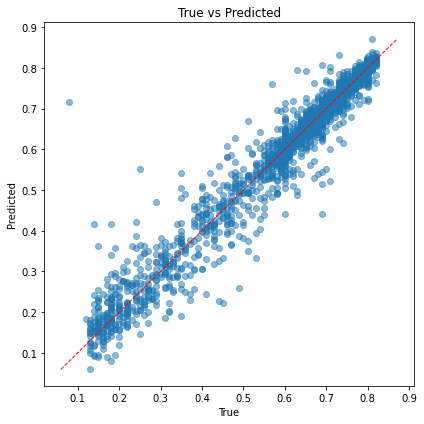


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,1,nan,nan,nan,nan
0.1-0.2,135,-9.2504,0.0037,0.0422,0.2638
0.2-0.3,136,-3.1964,0.0036,0.0440,0.1835
0.3-0.4,107,-3.9079,0.0038,0.0469,0.1362
0.4-0.5,143,-3.4376,0.0043,0.0476,0.1066
0.5-0.6,185,-2.6883,0.0025,0.0340,0.0616
0.6-0.7,1040,0.2370,0.0008,0.0165,0.0254
0.7-0.8,1029,0.5380,0.0003,0.0107,0.0144
0.8-0.9,479,-0.8436,0.0001,0.0051,0.0063



Average Segmented Metrics (skip NaN):
  R2:   -2.8187
  MSE:  0.0024
  MAE:  0.0309
  MAPE: 0.0997


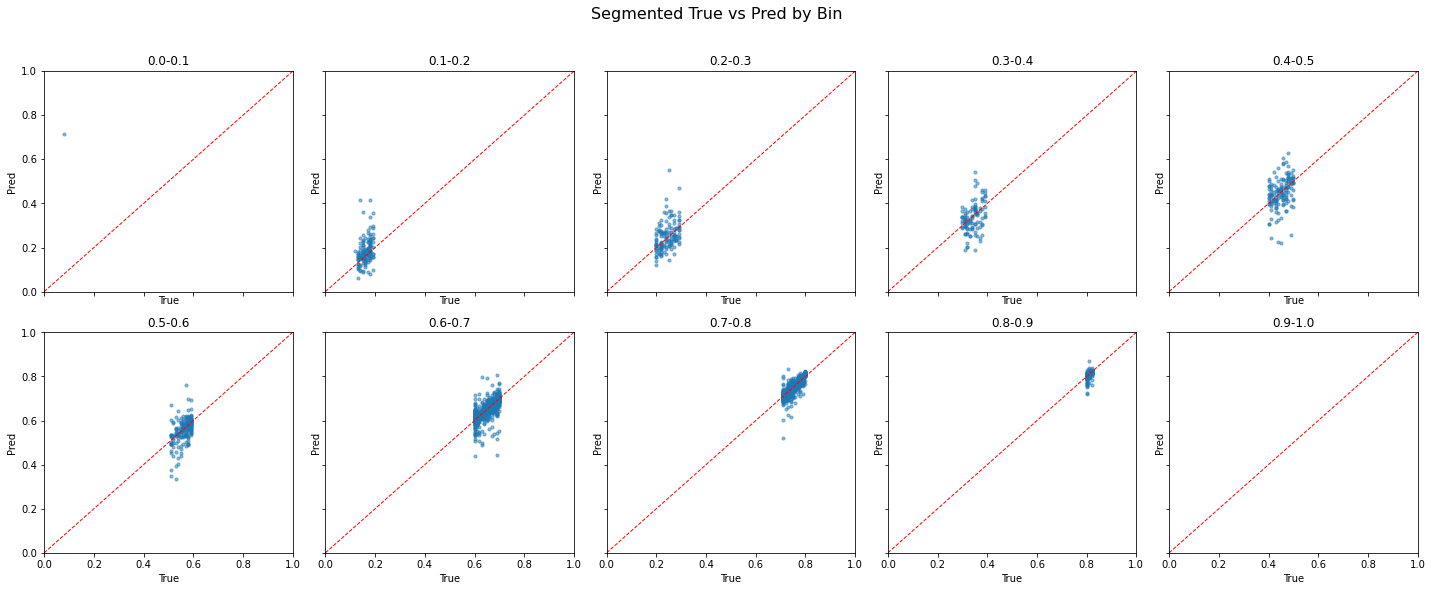

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense

# 构建 Bidirectional LSTM 模型
model_bilstm = Sequential([
    Bidirectional(LSTM(64), input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    Dense(1)
])

# 编译
model_bilstm.compile(optimizer='adam', loss='mse')

# 训练
model_bilstm.fit(
    X_seq_train, y_train,
    epochs=200, batch_size=32,
    verbose=2  # 关闭 validation_split
)

# 预测 & 评估
y_pred_bilstm = model_bilstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_bilstm)


Epoch 1/300
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-07-02 11:28:25.561428: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:690] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "CPU" vendor: "GenuineIntel" model: "110" frequency: 2300 num_cores: 8 environment { key: "cpu_instruction_set" value: "SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 49152 l2_cache_size: 524288 l3_cache_size: 8388608 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


407/407 - 6s - loss: 0.0184 - 6s/epoch - 14ms/step
Epoch 2/300
407/407 - 2s - loss: 0.0064 - 2s/epoch - 5ms/step
Epoch 3/300
407/407 - 2s - loss: 0.0043 - 2s/epoch - 5ms/step
Epoch 4/300
407/407 - 2s - loss: 0.0032 - 2s/epoch - 6ms/step
Epoch 5/300
407/407 - 2s - loss: 0.0029 - 2s/epoch - 6ms/step
Epoch 6/300
407/407 - 2s - loss: 0.0027 - 2s/epoch - 6ms/step
Epoch 7/300
407/407 - 2s - loss: 0.0026 - 2s/epoch - 6ms/step
Epoch 8/300
407/407 - 2s - loss: 0.0024 - 2s/epoch - 6ms/step
Epoch 9/300
407/407 - 2s - loss: 0.0023 - 2s/epoch - 6ms/step
Epoch 10/300
407/407 - 2s - loss: 0.0024 - 2s/epoch - 6ms/step
Epoch 11/300
407/407 - 2s - loss: 0.0021 - 2s/epoch - 6ms/step
Epoch 12/300
407/407 - 2s - loss: 0.0020 - 2s/epoch - 6ms/step
Epoch 13/300
407/407 - 2s - loss: 0.0020 - 2s/epoch - 6ms/step
Epoch 14/300
407/407 - 2s - loss: 0.0018 - 2s/epoch - 6ms/step
Epoch 15/300
407/407 - 2s - loss: 0.0018 - 2s/epoch - 6ms/step
Epoch 16/300
407/407 - 3s - loss: 0.0017 - 3s/epoch - 7ms/step
Epoch 17/300

Epoch 126/300
407/407 - 2s - loss: 3.6301e-04 - 2s/epoch - 5ms/step
Epoch 127/300
407/407 - 2s - loss: 3.7017e-04 - 2s/epoch - 5ms/step
Epoch 128/300
407/407 - 2s - loss: 3.6806e-04 - 2s/epoch - 6ms/step
Epoch 129/300
407/407 - 2s - loss: 3.5063e-04 - 2s/epoch - 6ms/step
Epoch 130/300
407/407 - 2s - loss: 3.4759e-04 - 2s/epoch - 6ms/step
Epoch 131/300
407/407 - 2s - loss: 3.4604e-04 - 2s/epoch - 5ms/step
Epoch 132/300
407/407 - 2s - loss: 3.2613e-04 - 2s/epoch - 5ms/step
Epoch 133/300
407/407 - 2s - loss: 3.5568e-04 - 2s/epoch - 6ms/step
Epoch 134/300
407/407 - 2s - loss: 3.3078e-04 - 2s/epoch - 6ms/step
Epoch 135/300
407/407 - 2s - loss: 3.3304e-04 - 2s/epoch - 6ms/step
Epoch 136/300
407/407 - 2s - loss: 3.1646e-04 - 2s/epoch - 6ms/step
Epoch 137/300
407/407 - 2s - loss: 3.3005e-04 - 2s/epoch - 6ms/step
Epoch 138/300
407/407 - 3s - loss: 3.4143e-04 - 3s/epoch - 7ms/step
Epoch 139/300
407/407 - 3s - loss: 3.0412e-04 - 3s/epoch - 7ms/step
Epoch 140/300
407/407 - 3s - loss: 3.0028e-04 - 

Epoch 247/300
407/407 - 3s - loss: 1.0915e-04 - 3s/epoch - 6ms/step
Epoch 248/300
407/407 - 3s - loss: 1.1942e-04 - 3s/epoch - 6ms/step
Epoch 249/300
407/407 - 3s - loss: 1.1128e-04 - 3s/epoch - 7ms/step
Epoch 250/300
407/407 - 3s - loss: 1.1122e-04 - 3s/epoch - 6ms/step
Epoch 251/300
407/407 - 3s - loss: 1.1705e-04 - 3s/epoch - 6ms/step
Epoch 252/300
407/407 - 3s - loss: 1.0490e-04 - 3s/epoch - 7ms/step
Epoch 253/300
407/407 - 3s - loss: 1.2658e-04 - 3s/epoch - 7ms/step
Epoch 254/300
407/407 - 3s - loss: 1.0273e-04 - 3s/epoch - 7ms/step
Epoch 255/300
407/407 - 3s - loss: 1.1088e-04 - 3s/epoch - 7ms/step
Epoch 256/300
407/407 - 3s - loss: 1.1557e-04 - 3s/epoch - 6ms/step
Epoch 257/300
407/407 - 3s - loss: 1.1371e-04 - 3s/epoch - 6ms/step
Epoch 258/300
407/407 - 3s - loss: 1.1738e-04 - 3s/epoch - 7ms/step
Epoch 259/300
407/407 - 3s - loss: 1.0973e-04 - 3s/epoch - 7ms/step
Epoch 260/300
407/407 - 3s - loss: 1.0491e-04 - 3s/epoch - 7ms/step
Epoch 261/300
407/407 - 3s - loss: 1.0309e-04 - 

2025-07-02 11:41:07.678238: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:690] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "CPU" vendor: "GenuineIntel" model: "110" frequency: 2300 num_cores: 8 environment { key: "cpu_instruction_set" value: "SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 49152 l2_cache_size: 524288 l3_cache_size: 8388608 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


102/102 [==============================] - 1s 3ms/step
Overall Metrics:


,Value
Metric,
MSE,0.0013
MAE,0.0194
MAPE,0.0484
R2,0.9583


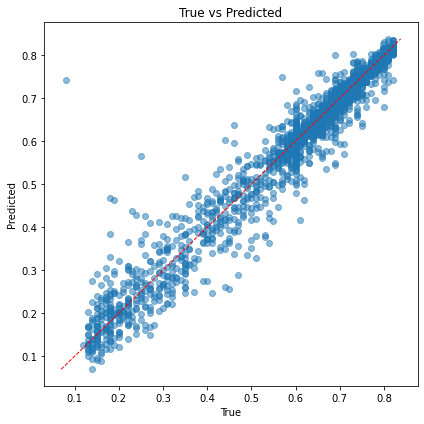


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,1,nan,nan,nan,nan
0.1-0.2,135,-9.6677,0.0039,0.0428,0.2616
0.2-0.3,136,-3.9449,0.0043,0.0462,0.1897
0.3-0.4,107,-3.1996,0.0033,0.0475,0.1397
0.4-0.5,143,-3.1063,0.0040,0.0474,0.1055
0.5-0.6,185,-2.6229,0.0024,0.0341,0.0617
0.6-0.7,1040,0.2690,0.0008,0.0168,0.0259
0.7-0.8,1029,0.5654,0.0003,0.0105,0.0141
0.8-0.9,479,-2.3349,0.0002,0.0087,0.0108



Average Segmented Metrics (skip NaN):
  R2:   -3.0052
  MSE:  0.0024
  MAE:  0.0317
  MAPE: 0.1011


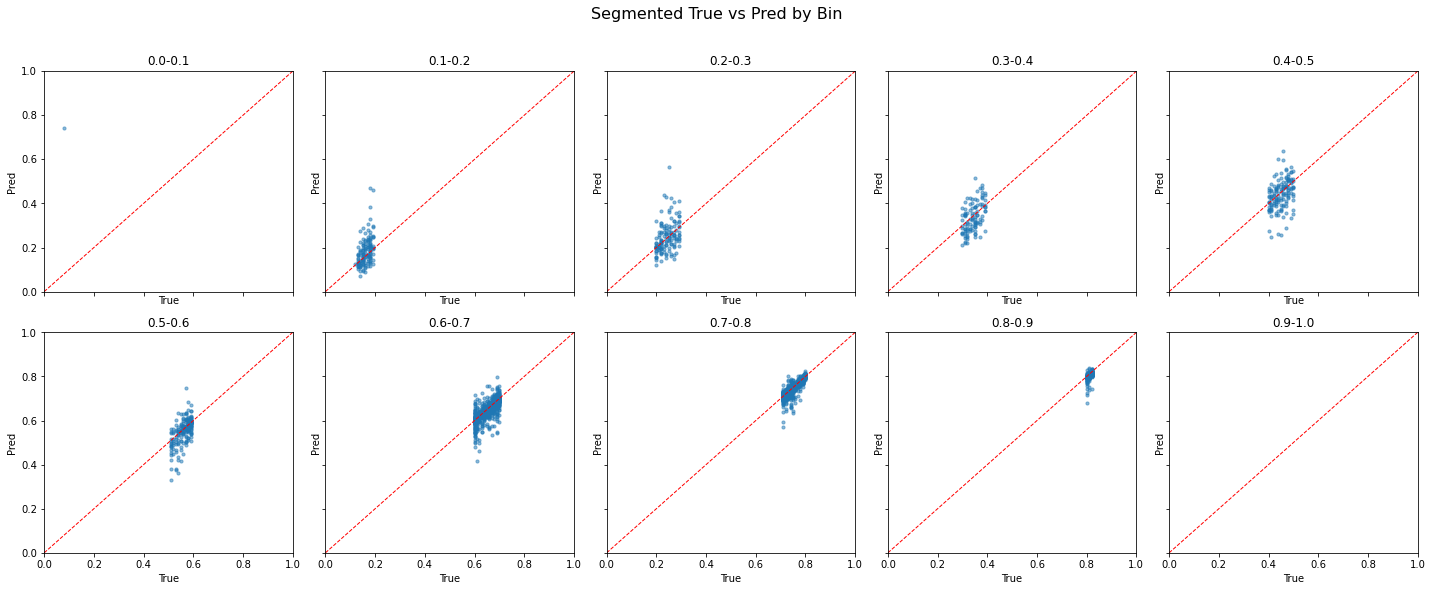

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Attention, Concatenate, RepeatVector

# LSTM + Attention 自定义模型
input_seq = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]))
lstm_out = LSTM(64, return_sequences=True)(input_seq)

# 注意力机制
attention = Attention()([lstm_out, lstm_out])
context = tf.reduce_mean(attention, axis=1)  # 聚合注意力上下文

# 输出层
output = Dense(1)(context)

# 构建模型
model_lstm_att = Model(inputs=input_seq, outputs=output)

# 编译模型
model_lstm_att.compile(optimizer='adam', loss='mse')

# 训练模型
model_lstm_att.fit(
    X_seq_train, y_train,
    epochs=300, batch_size=32,
    verbose=2
)

# 预测并评估
y_pred_att = model_lstm_att.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_att)


Epoch 1/300
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 8s - loss: 0.0129 - 8s/epoch - 21ms/step
Epoch 2/300
407/407 - 4s - loss: 0.0037 - 4s/epoch - 9ms/step
Epoch 3/300
407/407 - 4s - loss: 0.0028 - 4s/epoch - 9ms/step
Epoch 4/300
407/407 - 4s - loss: 0.0023 - 4s/epoch - 10ms/step
Epoch 5/300
407/407 - 5s - loss: 0.0021 - 5s/epoch - 11ms/step
Epoch 6/300
407/407 - 4s - loss: 0.0019 - 4s/epoch - 10ms/step
Ep

Epoch 110/300
407/407 - 5s - loss: 2.2428e-04 - 5s/epoch - 12ms/step
Epoch 111/300
407/407 - 5s - loss: 2.2467e-04 - 5s/epoch - 13ms/step
Epoch 112/300
407/407 - 5s - loss: 2.2724e-04 - 5s/epoch - 13ms/step
Epoch 113/300
407/407 - 5s - loss: 2.1638e-04 - 5s/epoch - 12ms/step
Epoch 114/300
407/407 - 5s - loss: 2.1032e-04 - 5s/epoch - 12ms/step
Epoch 115/300
407/407 - 4s - loss: 2.1850e-04 - 4s/epoch - 10ms/step
Epoch 116/300
407/407 - 4s - loss: 2.0119e-04 - 4s/epoch - 11ms/step
Epoch 117/300
407/407 - 5s - loss: 2.1632e-04 - 5s/epoch - 11ms/step
Epoch 118/300
407/407 - 7s - loss: 2.0087e-04 - 7s/epoch - 17ms/step
Epoch 119/300
407/407 - 7s - loss: 1.8646e-04 - 7s/epoch - 18ms/step
Epoch 120/300
407/407 - 7s - loss: 2.0304e-04 - 7s/epoch - 16ms/step
Epoch 121/300
407/407 - 7s - loss: 1.8934e-04 - 7s/epoch - 16ms/step
Epoch 122/300
407/407 - 7s - loss: 1.9315e-04 - 7s/epoch - 18ms/step
Epoch 123/300
407/407 - 7s - loss: 1.8694e-04 - 7s/epoch - 17ms/step
Epoch 124/300
407/407 - 7s - loss:

Epoch 229/300
407/407 - 4s - loss: 7.2491e-05 - 4s/epoch - 9ms/step
Epoch 230/300
407/407 - 4s - loss: 7.1152e-05 - 4s/epoch - 10ms/step
Epoch 231/300
407/407 - 4s - loss: 7.2517e-05 - 4s/epoch - 11ms/step
Epoch 232/300
407/407 - 4s - loss: 6.7339e-05 - 4s/epoch - 10ms/step
Epoch 233/300
407/407 - 4s - loss: 7.0362e-05 - 4s/epoch - 11ms/step
Epoch 234/300
407/407 - 4s - loss: 7.6532e-05 - 4s/epoch - 11ms/step
Epoch 235/300
407/407 - 3s - loss: 6.8111e-05 - 3s/epoch - 9ms/step
Epoch 236/300
407/407 - 3s - loss: 7.2393e-05 - 3s/epoch - 8ms/step
Epoch 237/300
407/407 - 3s - loss: 6.4415e-05 - 3s/epoch - 8ms/step
Epoch 238/300
407/407 - 3s - loss: 6.2446e-05 - 3s/epoch - 8ms/step
Epoch 239/300
407/407 - 4s - loss: 6.8611e-05 - 4s/epoch - 9ms/step
Epoch 240/300
407/407 - 3s - loss: 6.3942e-05 - 3s/epoch - 8ms/step
Epoch 241/300
407/407 - 3s - loss: 7.1890e-05 - 3s/epoch - 8ms/step
Epoch 242/300
407/407 - 4s - loss: 6.3973e-05 - 4s/epoch - 10ms/step
Epoch 243/300
407/407 - 3s - loss: 6.4744e

,Value
Metric,
MSE,0.0010
MAE,0.0160
MAPE,0.0415
R2,0.9657


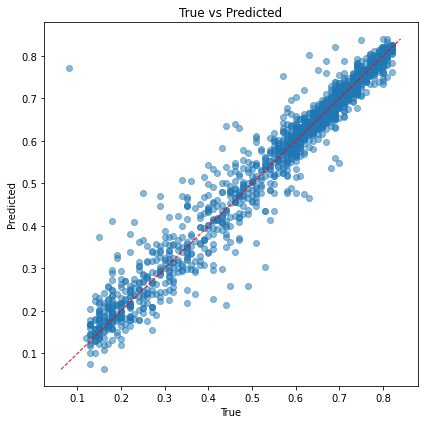


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,1,nan,nan,nan,nan
0.1-0.2,135,-6.1328,0.0026,0.0346,0.2155
0.2-0.3,136,-2.7183,0.0032,0.0410,0.1694
0.3-0.4,107,-3.3922,0.0034,0.0453,0.1323
0.4-0.5,143,-3.5692,0.0044,0.0464,0.1046
0.5-0.6,185,-2.2673,0.0022,0.0328,0.0591
0.6-0.7,1040,0.5389,0.0005,0.0130,0.0200
0.7-0.8,1029,0.7730,0.0001,0.0080,0.0107
0.8-0.9,479,-0.4550,0.0001,0.0041,0.0051



Average Segmented Metrics (skip NaN):
  R2:   -2.1528
  MSE:  0.0021
  MAE:  0.0282
  MAPE: 0.0896


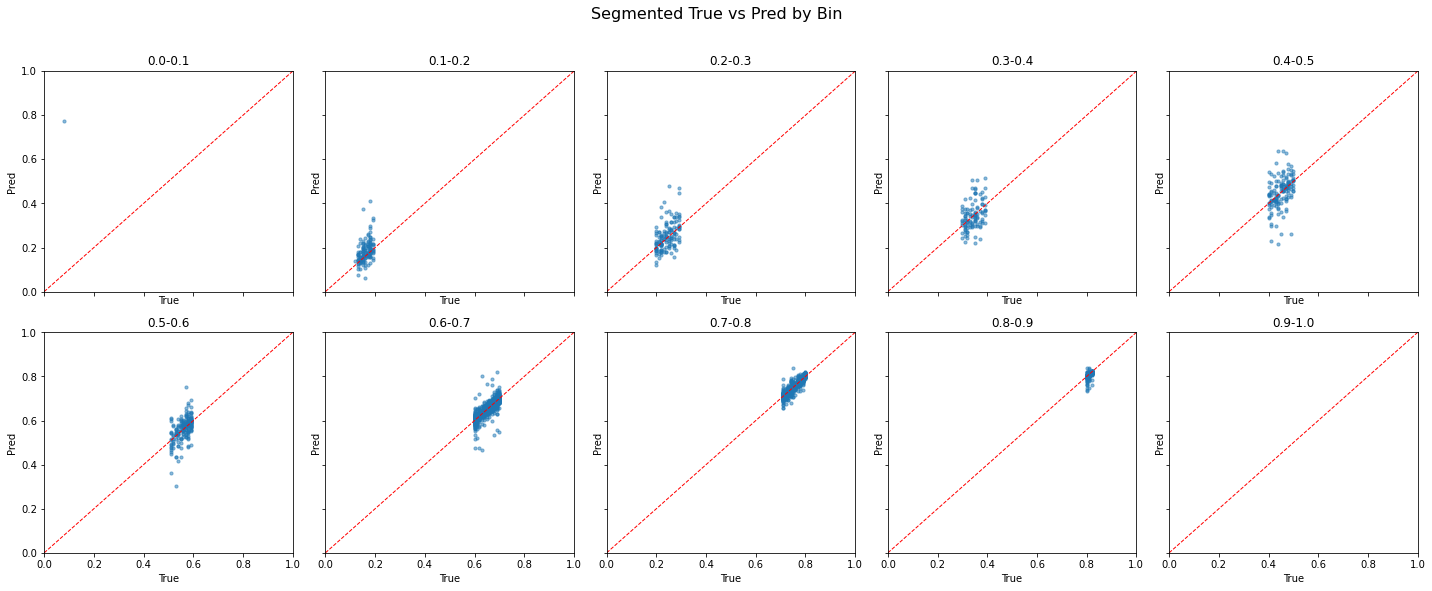

In [36]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 构建 Stacked LSTM 模型
model_stacked_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    LSTM(32),  # 第二层 LSTM
    Dense(1)   # 输出层
])

model_stacked_lstm.compile(optimizer='adam', loss='mse')

# 训练
model_stacked_lstm.fit(
    X_seq_train, y_train,
    epochs=300, batch_size=32,
    verbose=2
)

# 预测 + 评估
y_pred_stacked = model_stacked_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_stacked)



--- 3-Layer Stacked LSTM ---
Epoch 1/300
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 16s - loss: 0.0174 - 16s/epoch - 40ms/step
Epoch 2/300
407/407 - 8s - loss: 0.0070 - 8s/epoch - 21ms/step
Epoch 3/300
407/407 - 7s - loss: 0.0046 - 7s/epoch - 17ms/step
Epoch 4/300
407/407 - 8s - loss: 0.0035 - 8s/epoch - 19ms/step
Epoch 5/300
407/407 - 9s - loss: 0.0029 - 9s/epoch - 22ms/step
Epoch 6/300
407/407 - 8s - loss

Epoch 110/300
407/407 - 10s - loss: 3.2544e-04 - 10s/epoch - 24ms/step
Epoch 111/300
407/407 - 9s - loss: 3.2448e-04 - 9s/epoch - 21ms/step
Epoch 112/300
407/407 - 8s - loss: 3.2203e-04 - 8s/epoch - 21ms/step
Epoch 113/300
407/407 - 9s - loss: 3.1645e-04 - 9s/epoch - 22ms/step
Epoch 114/300
407/407 - 10s - loss: 3.1386e-04 - 10s/epoch - 24ms/step
Epoch 115/300
407/407 - 9s - loss: 3.1237e-04 - 9s/epoch - 21ms/step
Epoch 116/300
407/407 - 10s - loss: 3.1421e-04 - 10s/epoch - 24ms/step
Epoch 117/300
407/407 - 9s - loss: 3.1465e-04 - 9s/epoch - 22ms/step
Epoch 118/300
407/407 - 9s - loss: 3.1579e-04 - 9s/epoch - 22ms/step
Epoch 119/300
407/407 - 8s - loss: 3.0343e-04 - 8s/epoch - 19ms/step
Epoch 120/300
407/407 - 8s - loss: 2.9955e-04 - 8s/epoch - 20ms/step
Epoch 121/300
407/407 - 8s - loss: 3.0041e-04 - 8s/epoch - 21ms/step
Epoch 122/300
407/407 - 9s - loss: 2.8178e-04 - 9s/epoch - 21ms/step
Epoch 123/300
407/407 - 8s - loss: 2.8907e-04 - 8s/epoch - 20ms/step
Epoch 124/300
407/407 - 7s -

Epoch 229/300
407/407 - 7s - loss: 1.3873e-04 - 7s/epoch - 16ms/step
Epoch 230/300
407/407 - 6s - loss: 1.4354e-04 - 6s/epoch - 16ms/step
Epoch 231/300
407/407 - 7s - loss: 1.4549e-04 - 7s/epoch - 16ms/step
Epoch 232/300
407/407 - 7s - loss: 1.4617e-04 - 7s/epoch - 16ms/step
Epoch 233/300
407/407 - 6s - loss: 1.4314e-04 - 6s/epoch - 16ms/step
Epoch 234/300
407/407 - 7s - loss: 1.5456e-04 - 7s/epoch - 17ms/step
Epoch 235/300
407/407 - 7s - loss: 1.5369e-04 - 7s/epoch - 17ms/step
Epoch 236/300
407/407 - 7s - loss: 1.3881e-04 - 7s/epoch - 17ms/step
Epoch 237/300
407/407 - 7s - loss: 1.3718e-04 - 7s/epoch - 16ms/step
Epoch 238/300
407/407 - 6s - loss: 1.4175e-04 - 6s/epoch - 15ms/step
Epoch 239/300
407/407 - 6s - loss: 1.3273e-04 - 6s/epoch - 16ms/step
Epoch 240/300
407/407 - 6s - loss: 1.3789e-04 - 6s/epoch - 16ms/step
Epoch 241/300
407/407 - 7s - loss: 1.4268e-04 - 7s/epoch - 18ms/step
Epoch 242/300
407/407 - 7s - loss: 1.4933e-04 - 7s/epoch - 16ms/step
Epoch 243/300
407/407 - 6s - loss:

,Value
Metric,
MSE,0.0009
MAE,0.0157
MAPE,0.0401
R2,0.9686


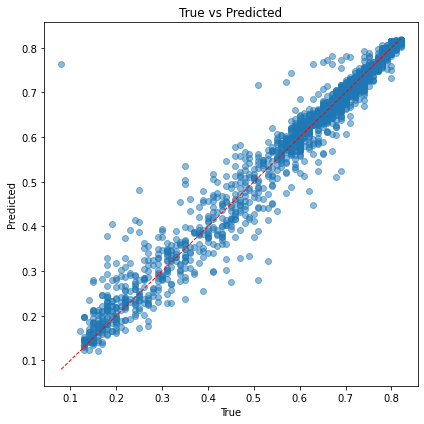


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,1,nan,nan,nan,nan
0.1-0.2,135,-5.7015,0.0024,0.0329,0.2018
0.2-0.3,136,-2.6322,0.0031,0.0405,0.1687
0.3-0.4,107,-2.5487,0.0028,0.0387,0.1130
0.4-0.5,143,-2.1893,0.0031,0.0439,0.0978
0.5-0.6,185,-2.3872,0.0023,0.0320,0.0581
0.6-0.7,1040,0.5127,0.0005,0.0133,0.0203
0.7-0.8,1029,0.7901,0.0001,0.0079,0.0106
0.8-0.9,479,0.1064,0.0000,0.0050,0.0061



Average Segmented Metrics (skip NaN):
  R2:   -1.7562
  MSE:  0.0018
  MAE:  0.0268
  MAPE: 0.0846


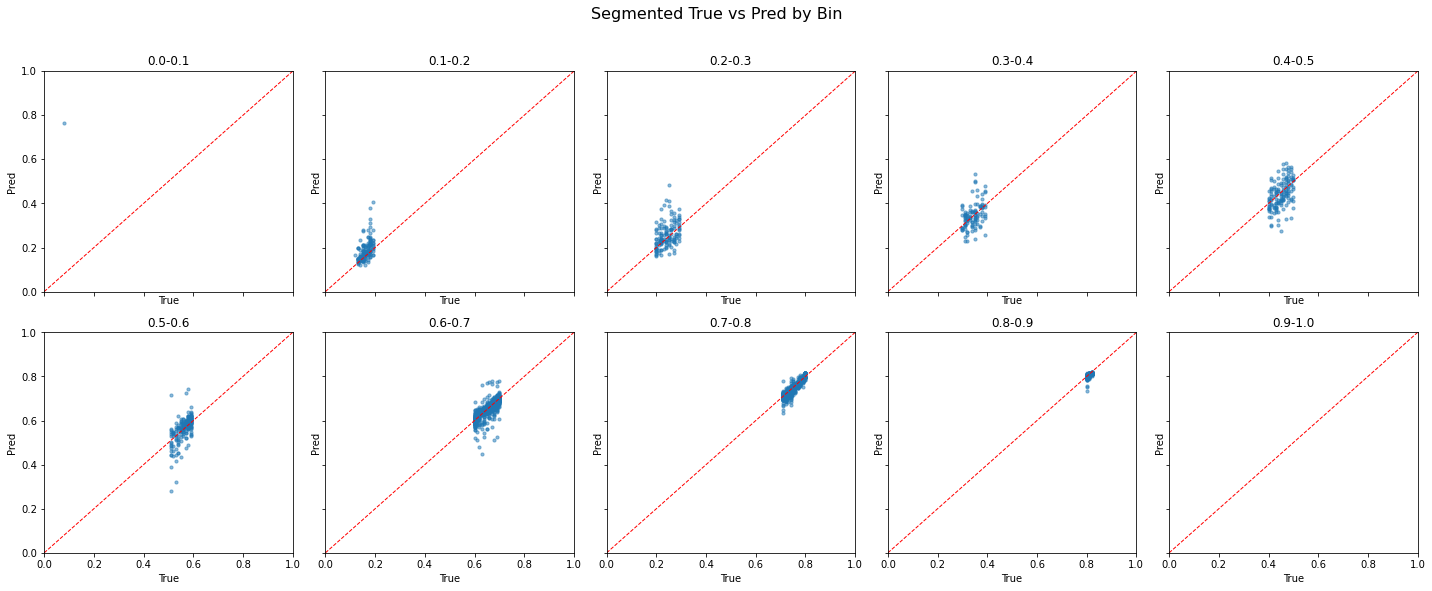

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_deep_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

model_deep_lstm.compile(optimizer='adam', loss='mse')

print("\n--- 3-Layer Stacked LSTM ---")
model_deep_lstm.fit(
    X_seq_train, y_train,
    epochs=300,
    batch_size=32,
    verbose=2
)

y_pred_deep_lstm = model_deep_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_deep_lstm)


Epoch 1/300
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing 

Epoch 98/300
407/407 - 3s - loss: 1.2146e-04 - 3s/epoch - 7ms/step
Epoch 99/300
407/407 - 3s - loss: 1.2094e-04 - 3s/epoch - 7ms/step
Epoch 100/300
407/407 - 3s - loss: 1.2956e-04 - 3s/epoch - 7ms/step
Epoch 101/300
407/407 - 3s - loss: 1.1987e-04 - 3s/epoch - 7ms/step
Epoch 102/300
407/407 - 3s - loss: 1.1439e-04 - 3s/epoch - 6ms/step
Epoch 103/300
407/407 - 3s - loss: 1.1553e-04 - 3s/epoch - 7ms/step
Epoch 104/300
407/407 - 3s - loss: 1.1266e-04 - 3s/epoch - 6ms/step
Epoch 105/300
407/407 - 3s - loss: 1.1161e-04 - 3s/epoch - 7ms/step
Epoch 106/300
407/407 - 3s - loss: 1.0778e-04 - 3s/epoch - 6ms/step
Epoch 107/300
407/407 - 3s - loss: 1.0895e-04 - 3s/epoch - 7ms/step
Epoch 108/300
407/407 - 3s - loss: 1.1058e-04 - 3s/epoch - 7ms/step
Epoch 109/300
407/407 - 3s - loss: 9.9983e-05 - 3s/epoch - 6ms/step
Epoch 110/300
407/407 - 3s - loss: 1.0311e-04 - 3s/epoch - 6ms/step
Epoch 111/300
407/407 - 3s - loss: 1.0092e-04 - 3s/epoch - 7ms/step
Epoch 112/300
407/407 - 3s - loss: 1.0167e-04 - 3s

Epoch 219/300
407/407 - 3s - loss: 3.7680e-05 - 3s/epoch - 6ms/step
Epoch 220/300
407/407 - 3s - loss: 3.4481e-05 - 3s/epoch - 7ms/step
Epoch 221/300
407/407 - 3s - loss: 3.2906e-05 - 3s/epoch - 7ms/step
Epoch 222/300
407/407 - 3s - loss: 3.1064e-05 - 3s/epoch - 7ms/step
Epoch 223/300
407/407 - 3s - loss: 3.3513e-05 - 3s/epoch - 6ms/step
Epoch 224/300
407/407 - 3s - loss: 3.7076e-05 - 3s/epoch - 7ms/step
Epoch 225/300
407/407 - 3s - loss: 3.5752e-05 - 3s/epoch - 7ms/step
Epoch 226/300
407/407 - 3s - loss: 3.2503e-05 - 3s/epoch - 7ms/step
Epoch 227/300
407/407 - 3s - loss: 3.1482e-05 - 3s/epoch - 7ms/step
Epoch 228/300
407/407 - 3s - loss: 3.3077e-05 - 3s/epoch - 7ms/step
Epoch 229/300
407/407 - 3s - loss: 3.2026e-05 - 3s/epoch - 7ms/step
Epoch 230/300
407/407 - 3s - loss: 3.0853e-05 - 3s/epoch - 7ms/step
Epoch 231/300
407/407 - 3s - loss: 2.8853e-05 - 3s/epoch - 7ms/step
Epoch 232/300
407/407 - 3s - loss: 3.1150e-05 - 3s/epoch - 7ms/step
Epoch 233/300
407/407 - 3s - loss: 4.2583e-05 - 

,Value
Metric,
MSE,0.0011
MAE,0.0167
MAPE,0.0424
R2,0.9630


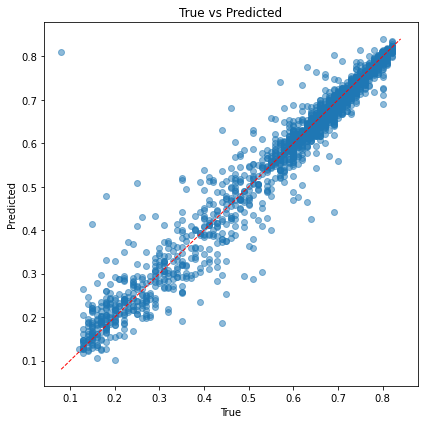


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,1,nan,nan,nan,nan
0.1-0.2,135,-7.2744,0.0030,0.0353,0.2195
0.2-0.3,136,-2.3895,0.0029,0.0381,0.1585
0.3-0.4,107,-3.3401,0.0034,0.0450,0.1304
0.4-0.5,143,-3.7459,0.0046,0.0493,0.1105
0.5-0.6,185,-2.4847,0.0023,0.0307,0.0559
0.6-0.7,1040,0.4207,0.0006,0.0143,0.0220
0.7-0.8,1029,0.7730,0.0001,0.0084,0.0113
0.8-0.9,479,-1.0934,0.0001,0.0053,0.0066



Average Segmented Metrics (skip NaN):
  R2:   -2.3918
  MSE:  0.0021
  MAE:  0.0283
  MAPE: 0.0893


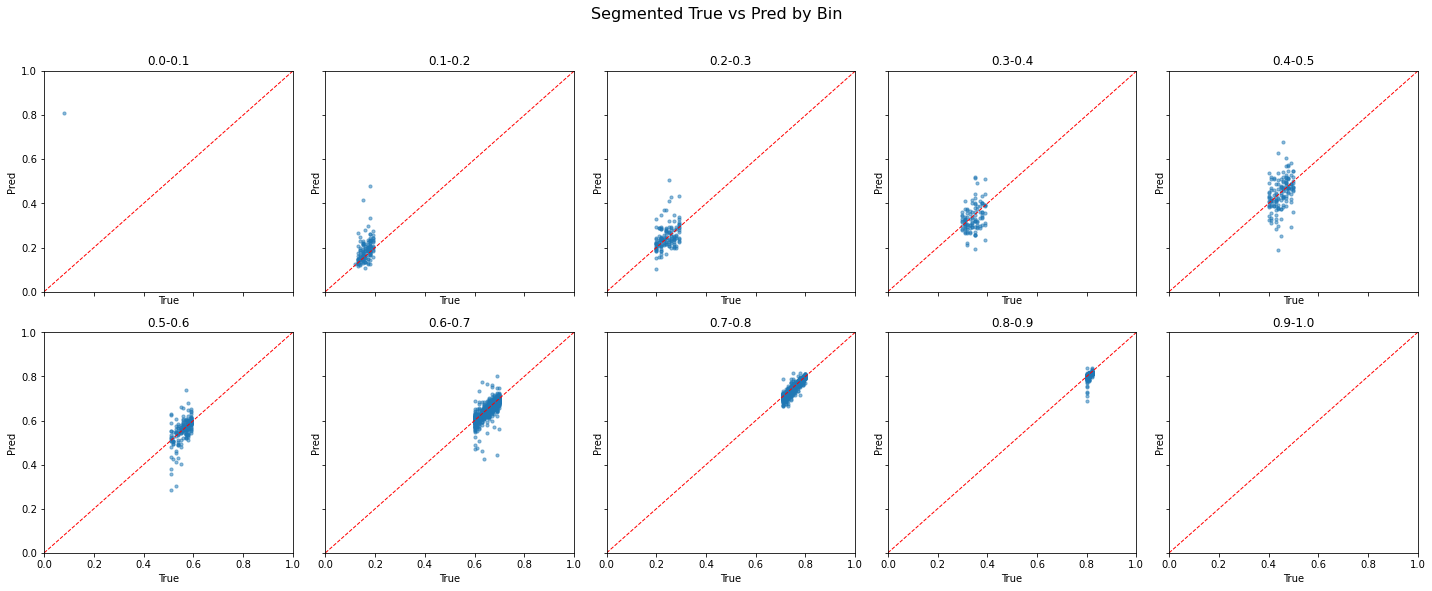

In [39]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# === 自定义 log-cosh loss ===
def log_cosh_loss(y_true, y_pred):
    return tf.reduce_mean(tf.math.log(tf.cosh(y_pred - y_true)))

# === 构建 Stacked LSTM 模型 ===
model_stacked_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    LSTM(32),
    Dense(1)
])

# === 使用 log-cosh loss 编译模型 ===
model_stacked_lstm.compile(optimizer='adam', loss=log_cosh_loss)

# === 训练模型 ===
model_stacked_lstm.fit(
    X_seq_train, y_train,
    epochs=300, batch_size=32,
    verbose=2
)

# === 预测并评估 ===
y_pred_stacked = model_stacked_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_stacked)


Epoch 1/300
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing 

Epoch 102/300
407/407 - 2s - loss: 5.1318e-04 - 2s/epoch - 6ms/step
Epoch 103/300
407/407 - 3s - loss: 4.7751e-04 - 3s/epoch - 6ms/step
Epoch 104/300
407/407 - 3s - loss: 4.9615e-04 - 3s/epoch - 6ms/step
Epoch 105/300
407/407 - 3s - loss: 4.9957e-04 - 3s/epoch - 6ms/step
Epoch 106/300
407/407 - 3s - loss: 4.3752e-04 - 3s/epoch - 6ms/step
Epoch 107/300
407/407 - 3s - loss: 4.7146e-04 - 3s/epoch - 6ms/step
Epoch 108/300
407/407 - 3s - loss: 4.3951e-04 - 3s/epoch - 7ms/step
Epoch 109/300
407/407 - 3s - loss: 4.4190e-04 - 3s/epoch - 6ms/step
Epoch 110/300
407/407 - 3s - loss: 4.1944e-04 - 3s/epoch - 7ms/step
Epoch 111/300
407/407 - 3s - loss: 4.2750e-04 - 3s/epoch - 6ms/step
Epoch 112/300
407/407 - 3s - loss: 4.4374e-04 - 3s/epoch - 6ms/step
Epoch 113/300
407/407 - 3s - loss: 4.1402e-04 - 3s/epoch - 6ms/step
Epoch 114/300
407/407 - 3s - loss: 3.9474e-04 - 3s/epoch - 6ms/step
Epoch 115/300
407/407 - 3s - loss: 4.0064e-04 - 3s/epoch - 6ms/step
Epoch 116/300
407/407 - 3s - loss: 3.9497e-04 - 

Epoch 223/300
407/407 - 3s - loss: 1.3502e-04 - 3s/epoch - 6ms/step
Epoch 224/300
407/407 - 3s - loss: 1.4018e-04 - 3s/epoch - 6ms/step
Epoch 225/300
407/407 - 3s - loss: 1.3718e-04 - 3s/epoch - 6ms/step
Epoch 226/300
407/407 - 2s - loss: 1.3102e-04 - 2s/epoch - 6ms/step
Epoch 227/300
407/407 - 3s - loss: 1.2778e-04 - 3s/epoch - 6ms/step
Epoch 228/300
407/407 - 3s - loss: 1.3738e-04 - 3s/epoch - 7ms/step
Epoch 229/300
407/407 - 3s - loss: 1.3407e-04 - 3s/epoch - 6ms/step
Epoch 230/300
407/407 - 2s - loss: 1.3206e-04 - 2s/epoch - 6ms/step
Epoch 231/300
407/407 - 3s - loss: 1.3329e-04 - 3s/epoch - 6ms/step
Epoch 232/300
407/407 - 3s - loss: 1.5185e-04 - 3s/epoch - 7ms/step
Epoch 233/300
407/407 - 3s - loss: 1.3603e-04 - 3s/epoch - 6ms/step
Epoch 234/300
407/407 - 3s - loss: 1.2700e-04 - 3s/epoch - 6ms/step
Epoch 235/300
407/407 - 3s - loss: 1.3094e-04 - 3s/epoch - 6ms/step
Epoch 236/300
407/407 - 3s - loss: 1.2135e-04 - 3s/epoch - 6ms/step
Epoch 237/300
407/407 - 3s - loss: 1.2300e-04 - 

,Value
Metric,
MSE,0.0010
MAE,0.0163
MAPE,0.0407
R2,0.9651


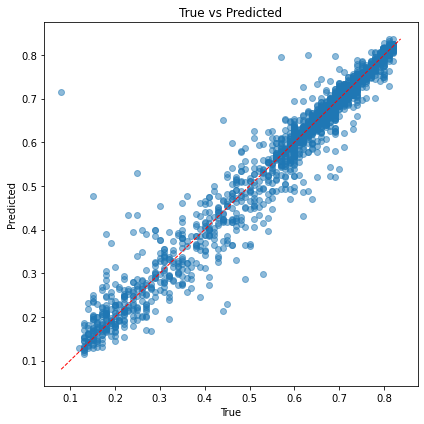


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,1,nan,nan,nan,nan
0.1-0.2,135,-6.9373,0.0029,0.0330,0.2042
0.2-0.3,136,-2.6044,0.0031,0.0373,0.1538
0.3-0.4,107,-2.4229,0.0027,0.0412,0.1208
0.4-0.5,143,-3.2320,0.0041,0.0462,0.1027
0.5-0.6,185,-2.5243,0.0024,0.0332,0.0602
0.6-0.7,1040,0.3755,0.0006,0.0147,0.0225
0.7-0.8,1029,0.7337,0.0002,0.0081,0.0109
0.8-0.9,479,-0.3978,0.0001,0.0046,0.0057



Average Segmented Metrics (skip NaN):
  R2:   -2.1262
  MSE:  0.0020
  MAE:  0.0273
  MAPE: 0.0851


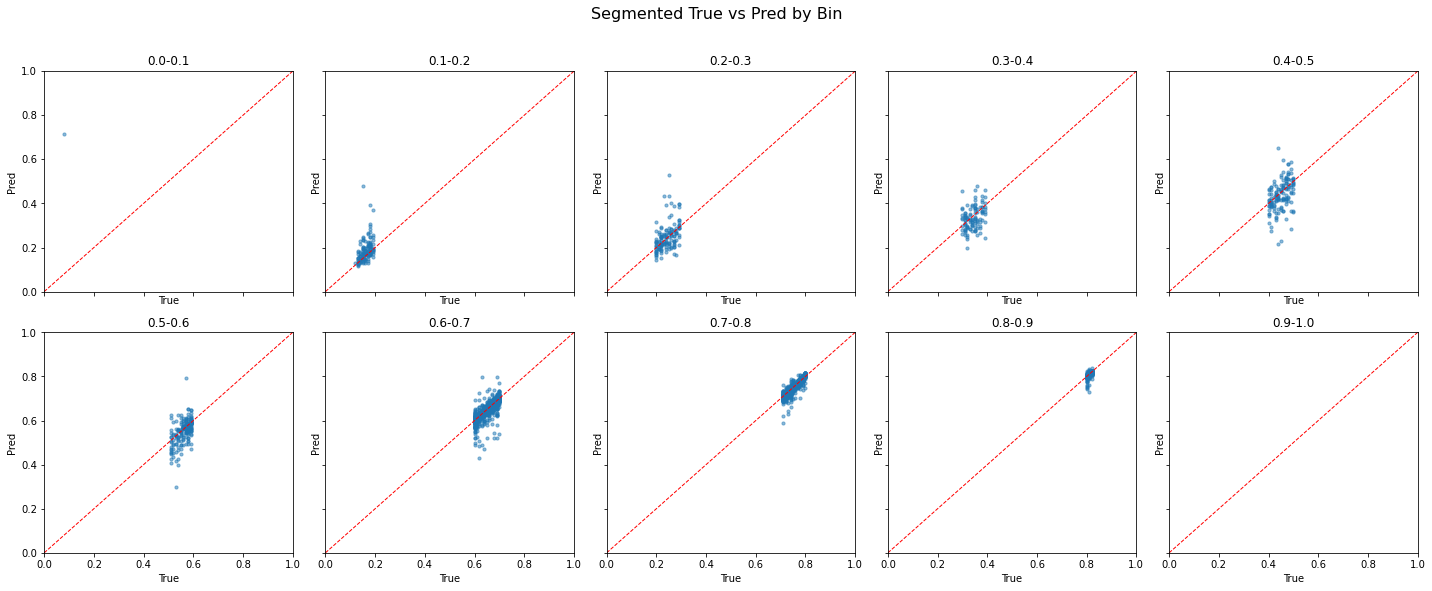

In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# === 自定义 Weighted MSE Loss ===
def weighted_mse(y_true, y_pred):
    # 权重设计：值越小权重越大，这里用 1 / (y_true + ε) 形式
    epsilon = 1e-3  # 防止除以 0
    weights = 1.0 / (y_true + epsilon)
    squared_errors = tf.square(y_true - y_pred)
    weighted_errors = weights * squared_errors
    return tf.reduce_mean(weighted_errors)

# === 构建 Stacked LSTM 模型 ===
model_weighted = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    LSTM(32),
    Dense(1)
])

# === 使用 Weighted MSE 编译模型 ===
model_weighted.compile(optimizer='adam', loss=weighted_mse)

# === 训练模型 ===
model_weighted.fit(
    X_seq_train, y_train,
    epochs=300, batch_size=32,
    verbose=2
)

# === 预测并评估 ===
y_pred_weighted = model_weighted.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_weighted)
